## Required Imports

In [7]:
# notebooks/08_matchup_analysis.ipynb

import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load all required data
vulnerability_df = pd.read_parquet(
    '../data/processed/batter_vulnerability.parquet'
)
pitcher_profiles = pd.read_parquet(
    '../data/processed/pitcher_profiles.parquet'
)
hitter_count_vuln = pd.read_parquet(
    '../data/processed/hitter_count_vulnerability.parquet'
)

# Load full data with recommendations
data = pd.read_parquet(
    '../data/processed/pitcher_data_with_recommendations.parquet'
)

print("All Phase 4 data loaded successfully")
print(f"Batters profiled: {vulnerability_df['batter'].nunique()}")
print(f"Pitchers profiled: {len(pitcher_profiles)}")

All Phase 4 data loaded successfully
Batters profiled: 402
Pitchers profiled: 14


## Build the Matchup Engine

In [8]:
def calculate_matchup_score(pitcher_name, batter_id, stand, data, 
                             vulnerability_df):
    """
    Calculate a matchup exploitation score for a specific
    pitcher-batter combination.
    
    Higher score = batter is better positioned to exploit 
    pitcher's deviation tendencies.
    """
    
    # Get pitcher's deviation substitution patterns
    pitcher_data = data[data['pitcher_name'] == pitcher_name].copy()
    deviations = pitcher_data[
        ~pitcher_data['followed_recommendation']
    ].copy()
    
    if len(deviations) == 0:
        return None
    
    # What does this pitcher actually throw when deviating?
    deviation_pitches = (
        deviations['pitch_type']
        .value_counts(normalize=True)
        .reset_index()
    )
    deviation_pitches.columns = ['pitch_type', 'deviation_frequency']
    
    # Get batter vulnerability against those pitches
    batter_vuln = vulnerability_df[
        (vulnerability_df['batter'] == batter_id) &
        (vulnerability_df['stand'] == stand)
    ][['pitch_type', 'vulnerability_score']]
    
    # Invert vulnerability — lower vulnerability = better for batter
    batter_vuln = batter_vuln.copy()
    batter_vuln['exploitation_score'] = (
        100 - batter_vuln['vulnerability_score']
    )
    
    # Merge deviation frequency with batter exploitation score
    matchup = deviation_pitches.merge(
        batter_vuln, on='pitch_type', how='inner'
    )
    
    if len(matchup) == 0:
        return None
    
    # Weighted matchup score
    matchup['weighted_score'] = (
        matchup['deviation_frequency'] * 
        matchup['exploitation_score']
    )
    
    total_score = matchup['weighted_score'].sum()
    
    return {
        'pitcher_name': pitcher_name,
        'batter_id': batter_id,
        'matchup_score': round(total_score, 2),
        'pitch_breakdown': matchup
    }

print("Matchup engine defined successfully")

Matchup engine defined successfully


## Run All Matchups

In [9]:
# Calculate matchup scores for all pitcher-batter combinations
matchup_records = []

pitchers = data['pitcher_name'].unique()
batters = vulnerability_df[['batter', 'batter_name', 'stand']].drop_duplicates()

print(f"Calculating matchups for {len(pitchers)} pitchers "
      f"x {len(batters)} batters...")

for pitcher in pitchers:
    for _, batter_row in batters.iterrows():
        result = calculate_matchup_score(
            pitcher,
            batter_row['batter'],
            batter_row['stand'],
            data,
            vulnerability_df
        )
        if result:
            matchup_records.append({
                'pitcher_name': result['pitcher_name'],
                'batter_id': batter_row['batter'],
                'batter_name': batter_row['batter_name'],
                'stand': batter_row['stand'],
                'matchup_score': result['matchup_score']
            })

matchup_df = pd.DataFrame(matchup_records)
print(f"Total matchups calculated: {len(matchup_df)}")
print(f"\nSample matchup scores:")
print(matchup_df.sort_values(
    'matchup_score', ascending=False
).head(10).to_string(index=False))

Calculating matchups for 14 pitchers x 415 batters...
Total matchups calculated: 5786

Sample matchup scores:
    pitcher_name  batter_id     batter_name stand  matchup_score
  Kyle Hendricks     457759   justin turner     R          63.61
  Framber Valdez     457759   justin turner     R          63.12
      Logan Webb     608324    alex bregman     R          62.85
      Chris Sale     457759   justin turner     R          62.43
    Max Scherzer     457759   justin turner     R          62.24
   Yusei Kikuchi     457759   justin turner     R          61.97
Justin Verlander     457759   justin turner     R          61.66
      Chris Sale     605141    mookie betts     R          61.30
 Spencer Strider     668939 adley rutschman     R          61.14
  Kyle Hendricks     543760   marcus semien     R          60.77


## Find Most Dangerous Matchups Per Pitcher

In [10]:
# For each pitcher find the batters most likely to exploit their deviations
print("=== Most Dangerous Matchups by Pitcher ===")
print("(Highest score = batter best positioned to exploit pitcher)\n")

for pitcher in sorted(pitchers):
    pitcher_matchups = matchup_df[
        matchup_df['pitcher_name'] == pitcher
    ].sort_values('matchup_score', ascending=False)
    
    print(f"\n{pitcher} — Top 5 Most Dangerous Batters:")
    print(pitcher_matchups[['batter_name', 'stand', 'matchup_score']]
          .head(5).to_string(index=False))

=== Most Dangerous Matchups by Pitcher ===
(Highest score = batter best positioned to exploit pitcher)


Chris Sale — Top 5 Most Dangerous Batters:
    batter_name stand  matchup_score
  justin turner     R          62.43
   mookie betts     R          61.30
   alex verdugo     L          60.29
  marcus semien     R          59.89
george springer     R          59.80

Corbin Burnes — Top 5 Most Dangerous Batters:
   batter_name stand  matchup_score
 justin turner     R          59.62
   lane thomas     R          56.42
  alex bregman     R          56.34
    tommy pham     R          55.42
gleyber torres     R          54.77

Dylan Cease — Top 5 Most Dangerous Batters:
  batter_name stand  matchup_score
  josh naylor     L          56.93
 mookie betts     R          54.56
justin turner     R          53.42
isaac paredes     R          52.96
  luis arráez     L          52.94

Framber Valdez — Top 5 Most Dangerous Batters:
  batter_name stand  matchup_score
justin turner     R          

## Visualize Matchup Heatmap

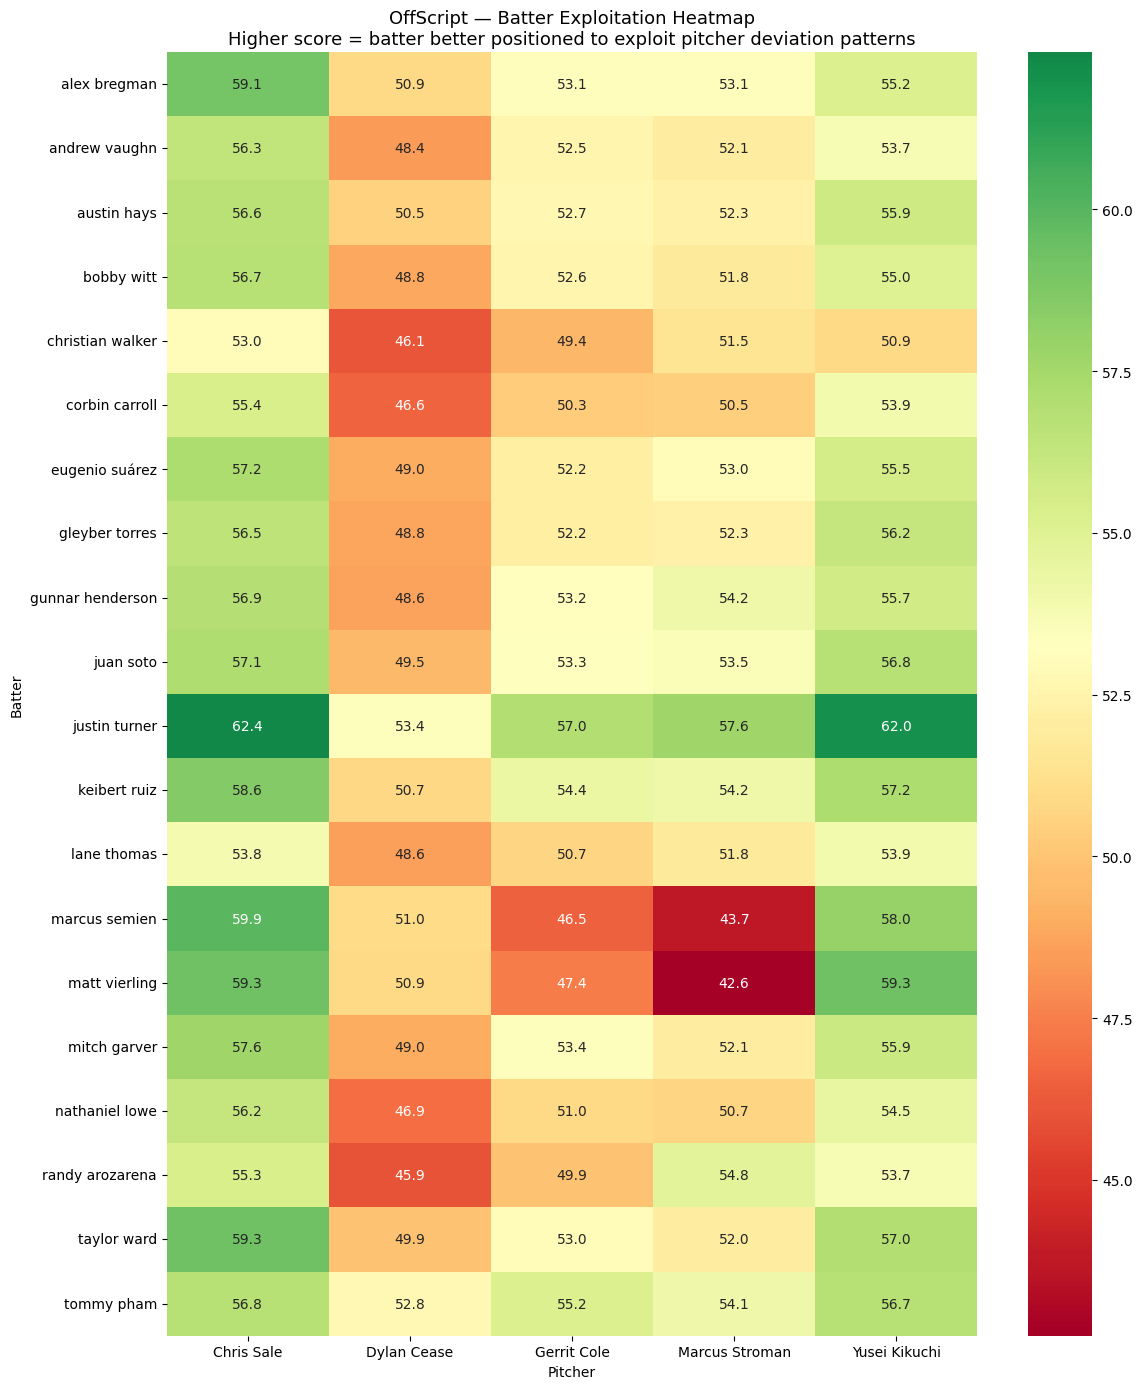

In [11]:
# Create a pitcher vs batter matchup heatmap for top deviators
top_deviators = ['Chris Sale', 'Yusei Kikuchi', 'Gerrit Cole', 
                  'Marcus Stroman', 'Dylan Cease']

# Get top 20 batters by average matchup score
top_batters = (matchup_df.groupby('batter_name')['matchup_score']
               .mean()
               .sort_values(ascending=False)
               .head(20)
               .index.tolist())

heatmap_data = matchup_df[
    (matchup_df['pitcher_name'].isin(top_deviators)) &
    (matchup_df['batter_name'].isin(top_batters))
].pivot_table(
    index='batter_name',
    columns='pitcher_name',
    values='matchup_score'
).fillna(0)

fig, ax = plt.subplots(figsize=(12, 14))
sns.heatmap(heatmap_data,
            annot=True,
            fmt='.1f',
            cmap='RdYlGn',
            ax=ax,
            center=heatmap_data.values.mean())
ax.set_title("OffScript — Batter Exploitation Heatmap\n"
             "Higher score = batter better positioned to "
             "exploit pitcher deviation patterns",
             fontsize=13)
ax.set_xlabel("Pitcher")
ax.set_ylabel("Batter")
plt.tight_layout()
plt.savefig('../reports/figures/matchup_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()

## Save Matchup Data

In [12]:
matchup_df.to_parquet(
    '../data/processed/matchup_scores.parquet',
    index=False
)
print(f"Matchup scores saved: {len(matchup_df)} records")

Matchup scores saved: 5786 records
